# Rubin On-Axis Donuts: Geometric, fftPSF and Huygens/Debye Diffraction (v1)

**Author:** Aaron Roodman (with Claude)
**Date Created:** 2026-09-30
**Last Modified:** 2026-09-30
**Status:** Complete
**Keywords:** Fresnel, Debye, Huygens, diffraction, donut, intra-focal, extra-focal, batoid, fftPSF, NUFFT, Rubin

## Description

On-axis donuts for the Rubin design prescription (`LSST_r.yaml`, r band,
622 nm), with the whole camera (lenses, filter and detector) pistoned ±1.5 mm, as in
full-array-mode (FAM) defocused data. For this prescription the beam travels toward +z
at the camera, so +1.5 mm is extra-focal and −1.5 mm is intra-focal.

Models compared for each side of focus:
1. **Huygens/Debye sum with Debye-Wolf ray weights**, evaluated by NUFFT. This is the
   reference; the annular-paraboloid benchmark
   (`optics_fresnel_analytic_benchmark_v1.ipynb`) validates it against a semi-analytic
   Debye integral to ~1×10⁻³ RMS of the peak irradiance.
2. **batoid's Huygens sum with its default unit ray weights** (`huygensPSF` algorithm),
   also by NUFFT.
3. **batoid `fftPSF`**.
4. **Geometric ray tracing**: 2×10⁷ random rays.

The main questions: how large the diffraction signal is at the 10 µm pixel scale; how
well batoid's `fftPSF` and unit-weight Huygens do for a real Rubin donut, compared with
the paraboloid stress test; and how the intra- and extra-focal donuts differ.

**Output:** figures in `optics/output/fresnel/`.

**Based on:** `optics/docs/studies/fresnel_donuts.md`,
`optics_fresnel_analytic_benchmark_v1.ipynb`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-30 | Aaron Roodman (with Claude) | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Optic, ray grid and Debye weights](#optic)
5. [Sampling convergence](#convergence)
6. [Donuts: all models, both sides of focus](#donuts)
7. [Radial profiles](#profiles)
8. [Pixel-level comparison (10 µm pixels)](#pixels)
9. [fftPSF sample by sample, and the reference-sphere radius](#fftpsf)
10. [Intra- versus extra-focal](#intraextra)
11. [Conclusions](#conclusions)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================
prescription = 'LSST_r.yaml'   # batoid design prescription, r band
wavelength = 622e-9            # m
defocus_values = {'intra': -1.5e-3, 'extra': +1.5e-3}   # m, camera piston (FAM)
theta_x, theta_y = 0.0, 0.0    # rad, on axis

nx_pupil = 2560                # rays across the entrance-pupil grid
nx_pupil_check = 3584          # larger grid for the convergence check
dx_image = 0.5e-6              # m, Huygens/NUFFT image sample spacing
npix_image = 3200              # samples per side (1.6 mm field)
n_geometric_rays = 20_000_000  # random rays per side for the geometric image

annulus_width = 2e-6           # m, radial-profile annulus width
pixel_size = 10e-6             # m, LSSTCam pixel
npix_pixel = 160               # pixels per side of the pixel-level images

output_date = '20260930'

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'common').is_dir())))
from common.utils import setup_plotting, repo_root

root = repo_root()
sys.path.insert(0, str(root / 'optics' / 'code' / 'fresnel'))
import fresnel_donut as fd     # imports finufft before batoid (OpenMP order)
import batoid

setup_plotting()
output_dir = root / 'optics' / 'output' / 'fresnel'
output_dir.mkdir(parents=True, exist_ok=True)
print('batoid', batoid.__version__)

batoid 0.8.1


<a id='functions'></a>
## Helper Functions

In [3]:
r_edges = np.arange(0, 0.8e-3 + 1e-12, annulus_width)
r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
annulus_area = np.pi * np.diff(r_edges**2)


def grid_profile(img, xs, ys, center):
    X, Y = np.meshgrid(xs, ys)
    return fd.radial_profile(X.ravel(), Y.ravel(), img.ravel(), center, r_edges)


def grid_pixels(img, xs, ys, center):
    X, Y = np.meshgrid(xs, ys)
    return fd.bin_to_pixels(X.ravel(), Y.ravel(), img.ravel(), center, pixel_size,
                            npix_pixel)


def enclosed_radii(profile, fractions=(0.02, 0.5, 0.98)):
    # Radii (m) enclosing the given fractions of total flux.
    cum = np.cumsum(profile * annulus_area)
    return np.interp(fractions, cum / cum[-1], r_edges[1:])


def pixel_stats(img, ref):
    # RMS residual over pixels with ref > 5% of its peak, as a fraction of the
    # reference peak pixel; and total absolute flux moved, as a fraction of flux.
    d = img - ref
    m = ref > 0.05 * ref.max()
    return np.sqrt(np.mean(d[m]**2)) / ref.max(), np.abs(d).sum()


def run_models(optic, nx, with_fft=True, with_geo=True):
    # All image models for one optic. Returns a dict of results.
    out = {}
    center = fd.chief_ray_point(optic, wavelength, theta_x, theta_y)
    out['center'] = center
    t0 = time.perf_counter()
    rays = fd.trace_pupil_grid(optic, wavelength, nx, theta_x, theta_y)
    out['t_trace'] = time.perf_counter() - t0
    w, g = fd.debye_weights(rays, nx)
    good = ~rays.vignetted
    out['weights'] = (w, g, good)
    t0 = time.perf_counter()
    out['img_w'], xs, ys = fd.huygens_image(rays, wavelength, center, dx_image,
                                            npix_image, weights=w, gamma=g)
    out['t_nufft'] = time.perf_counter() - t0
    out['img_u'], _, _ = fd.huygens_image(rays, wavelength, center, dx_image, npix_image)
    out['xs'], out['ys'] = xs, ys
    out['rays'] = rays
    if with_fft:
        x, y, v, sp = fd.fftpsf_samples(optic, wavelength, nx, 1, theta_x, theta_y)
        out['fft'] = (x + center[0], y + center[1], v)
    if with_geo:
        out['geo'] = fd.geometric_positions(optic, wavelength, n_geometric_rays,
                                            theta_x, theta_y)
    return out

<a id='optic'></a>
## 1. Optic, ray grid and Debye weights

The Debye-Wolf weight per ray, sqrt(dΩ/d²u), measures how unevenly Rubin maps uniform
entrance-pupil area onto ray direction at the detector (pupil distortion). A system
obeying the sine condition with no pupil distortion would have a nearly flat weight;
the annular paraboloid varies by ±1.3% (fraction of the mean amplitude weight,
dimensionless).

In [4]:
telescope = batoid.Optic.fromYaml(prescription)
optics = {side: fd.shift_camera(telescope, dz) for side, dz in defocus_values.items()}
res = {}
for side, optic in optics.items():
    t0 = time.perf_counter()
    res[side] = run_models(optic, nx_pupil)
    r = res[side]
    w, g, good = r['weights']
    print(f"{side}: camera piston {defocus_values[side]*1e3:+.1f} mm; "
          f"{good.sum()} of {len(w)} grid rays unvignetted; trace {r['t_trace']:.1f} s, "
          f"NUFFT image {r['t_nufft']:.1f} s, all models {time.perf_counter()-t0:.1f} s")
    print(f"   chief-ray point ({r['center'][0]*1e6:.3f}, {r['center'][1]*1e6:.3f}) um; "
          f"Debye weight range {w[good].min():.4f} to {w[good].max():.4f} "
          f"(dimensionless, mean 1); gamma range {g[good].min():.4f} to {g[good].max():.4f}")

intra: camera piston -1.5 mm; 3214412 of 6553600 grid rays unvignetted; trace 7.0 s, NUFFT image 1.3 s, all models 38.3 s
   chief-ray point (0.000, 0.000) um; Debye weight range 0.9858 to 1.0149 (dimensionless, mean 1); gamma range 0.9141 to 0.9687


extra: camera piston +1.5 mm; 3214412 of 6553600 grid rays unvignetted; trace 7.1 s, NUFFT image 1.4 s, all models 39.6 s
   chief-ray point (0.000, 0.000) um; Debye weight range 0.9859 to 1.0148 (dimensionless, mean 1); gamma range 0.9142 to 0.9687


intra: geometric donut inner radius 389.5 um, outer radius 671.2 um
extra: geometric donut inner radius 378.3 um, outer radius 674.7 um


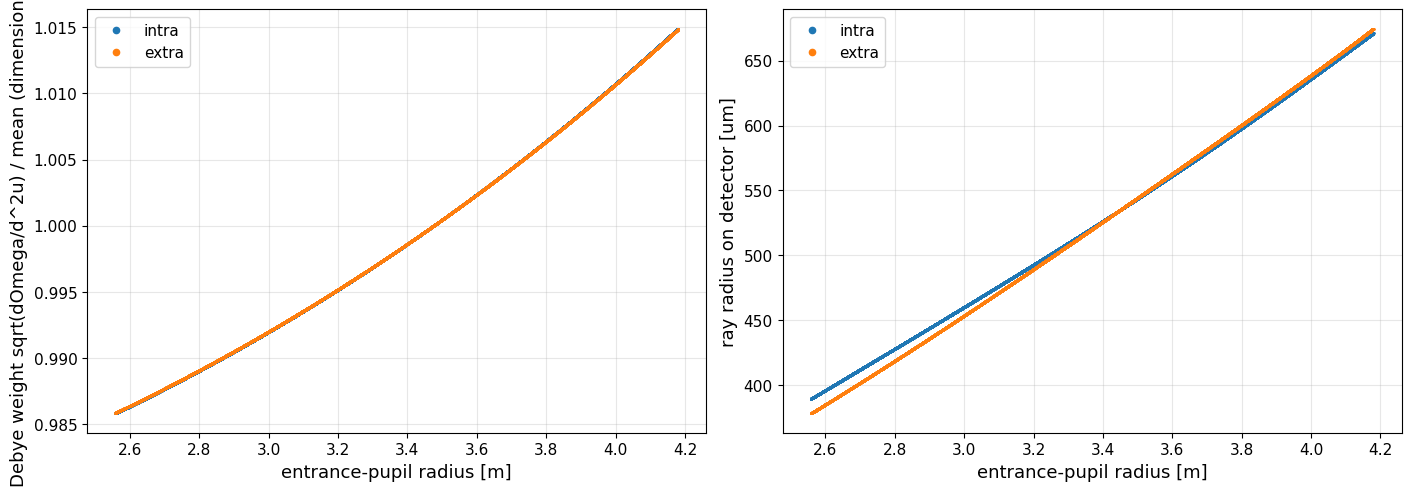

In [5]:
# Radial dependence of the Debye weight across the pupil, and the geometric donut edges
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for side, r in res.items():
    w, g, good = r['weights']
    rays = r['rays']
    pupil = batoid.RayVector.asGrid(optic=optics[side], wavelength=wavelength,
                                    dirCos=fd.dircos(theta_x, theta_y), nx=nx_pupil)
    h = np.hypot(pupil.x, pupil.y)
    sel = good & (np.arange(len(h)) % 97 == 0)
    axes[0].plot(h[sel], w[sel], '.', ms=1.5, label=side)
    axes[1].plot(h[sel], np.hypot(rays.x[sel] - r['center'][0],
                                  rays.y[sel] - r['center'][1]) * 1e6, '.', ms=1.5,
                 label=side)
axes[0].set_xlabel('entrance-pupil radius [m]')
axes[0].set_ylabel('Debye weight sqrt(dOmega/d^2u) / mean (dimensionless)')
axes[1].set_xlabel('entrance-pupil radius [m]')
axes[1].set_ylabel('ray radius on detector [um]')
for a in axes:
    a.legend(markerscale=6)
fig.savefig(output_dir / f'optics_fresnel_rubin_weights_{output_date}.png', dpi=120)

for side, r in res.items():
    xg, yg = r['geo']
    rg = np.hypot(xg - r['center'][0], yg - r['center'][1])
    print(f'{side}: geometric donut inner radius {rg.min()*1e6:.1f} um, '
          f'outer radius {rg.max()*1e6:.1f} um')

### Sine condition

If the transverse direction cosines (α, β) at the detector are linear in
entrance-pupil position (the Abbe sine condition, sin θ = h/f), the Jacobian
dα dβ/d²u is constant. Two consequences follow. The Debye weight
sqrt(dΩ/d²u) = sqrt(dα dβ/d²u / γ) then exactly cancels the γ in the flux
projection, so batoid's unit ray weights give the correct irradiance. And the
linear pupil-to-direction map assumed by `fftPSF` becomes exact. The annular
paraboloid of the benchmark notebook breaks the sine condition (sin θ =
(h/f)·cos²(θ/2)), and both batoid shortcuts failed there.

In [6]:
def sine_condition_stats(optic, nx=1024):
    rays = fd.trace_pupil_grid(optic, wavelength, nx, theta_x, theta_y)
    w, g = fd.debye_weights(rays, nx)
    good = ~rays.vignetted
    pupil = batoid.RayVector.asGrid(optic=optic, wavelength=wavelength,
                                    dirCos=fd.dircos(theta_x, theta_y), nx=nx)
    h = np.hypot(pupil.x, pupil.y)[good]
    v = np.stack([rays.vx, rays.vy, rays.vz])[:, good]
    sin_t = np.hypot(v[0], v[1]) / np.sqrt(np.sum(v**2, axis=0))
    jac = (w**2 * g)[good]
    return (np.std(sin_t / h) / np.mean(sin_t / h), 1 / np.mean(sin_t / h),
            np.std(jac) / np.mean(jac))

for name, optic in [('Rubin extra-focal', optics['extra']),
                    ('annular paraboloid', fd.make_parabola(defocus=1.5e-3))]:
    s_rel, f_eff, j_rel = sine_condition_stats(optic)
    print(f'{name:20s}: std(sin theta / h)/mean = {s_rel:.1e}, '
          f'f_eff = {f_eff:.4f} m, std(dalpha dbeta/d2u)/mean = {j_rel:.1e} (dimensionless)')

Rubin extra-focal   : std(sin theta / h)/mean = 8.6e-06, f_eff = 10.3115 m, std(dalpha dbeta/d2u)/mean = 1.6e-05 (dimensionless)
annular paraboloid  : std(sin theta / h)/mean = 7.2e-03, f_eff = 10.6006 m, std(dalpha dbeta/d2u)/mean = 2.9e-02 (dimensionless)


<a id='convergence'></a>
## 2. Sampling convergence

The Debye-weighted Huygens image from the 2560² pupil grid is compared with a 3584²
grid (extra-focal), as RMS and maximum profile differences relative to the peak
irradiance.

In [7]:
check = run_models(optics['extra'], nx_pupil_check, with_fft=False, with_geo=False)
p_a = grid_profile(res['extra']['img_w'], res['extra']['xs'], res['extra']['ys'],
                   res['extra']['center'])
p_b = grid_profile(check['img_w'], check['xs'], check['ys'], check['center'])
d = p_b - p_a
print(f'Huygens profile, 3584^2 vs 2560^2 pupil grid: rms {np.sqrt(np.mean(d**2))/p_a.max():.1e}, '
      f'max {np.max(np.abs(d))/p_a.max():.1e} (fraction of peak irradiance)')
pa = grid_pixels(res['extra']['img_w'], res['extra']['xs'], res['extra']['ys'],
                 res['extra']['center'])
pb = grid_pixels(check['img_w'], check['xs'], check['ys'], check['center'])
print(f'10 um pixel images: rms residual {pixel_stats(pb, pa)[0]:.1e} '
      f'(fraction of peak pixel), flux moved {pixel_stats(pb, pa)[1]:.1e} (fraction of flux)')
del check

Huygens profile, 3584^2 vs 2560^2 pupil grid: rms 1.3e-04, max 4.1e-04 (fraction of peak irradiance)


10 um pixel images: rms residual 5.2e-04 (fraction of peak pixel), flux moved 7.7e-04 (fraction of flux)


<a id='donuts'></a>
## 3. Donuts: all models, both sides of focus

Top row: the Debye-weighted Huygens reference at 0.5 µm sampling, with a zoom on the
outer edge. Bottom rows: 10 µm pixel images of each model.

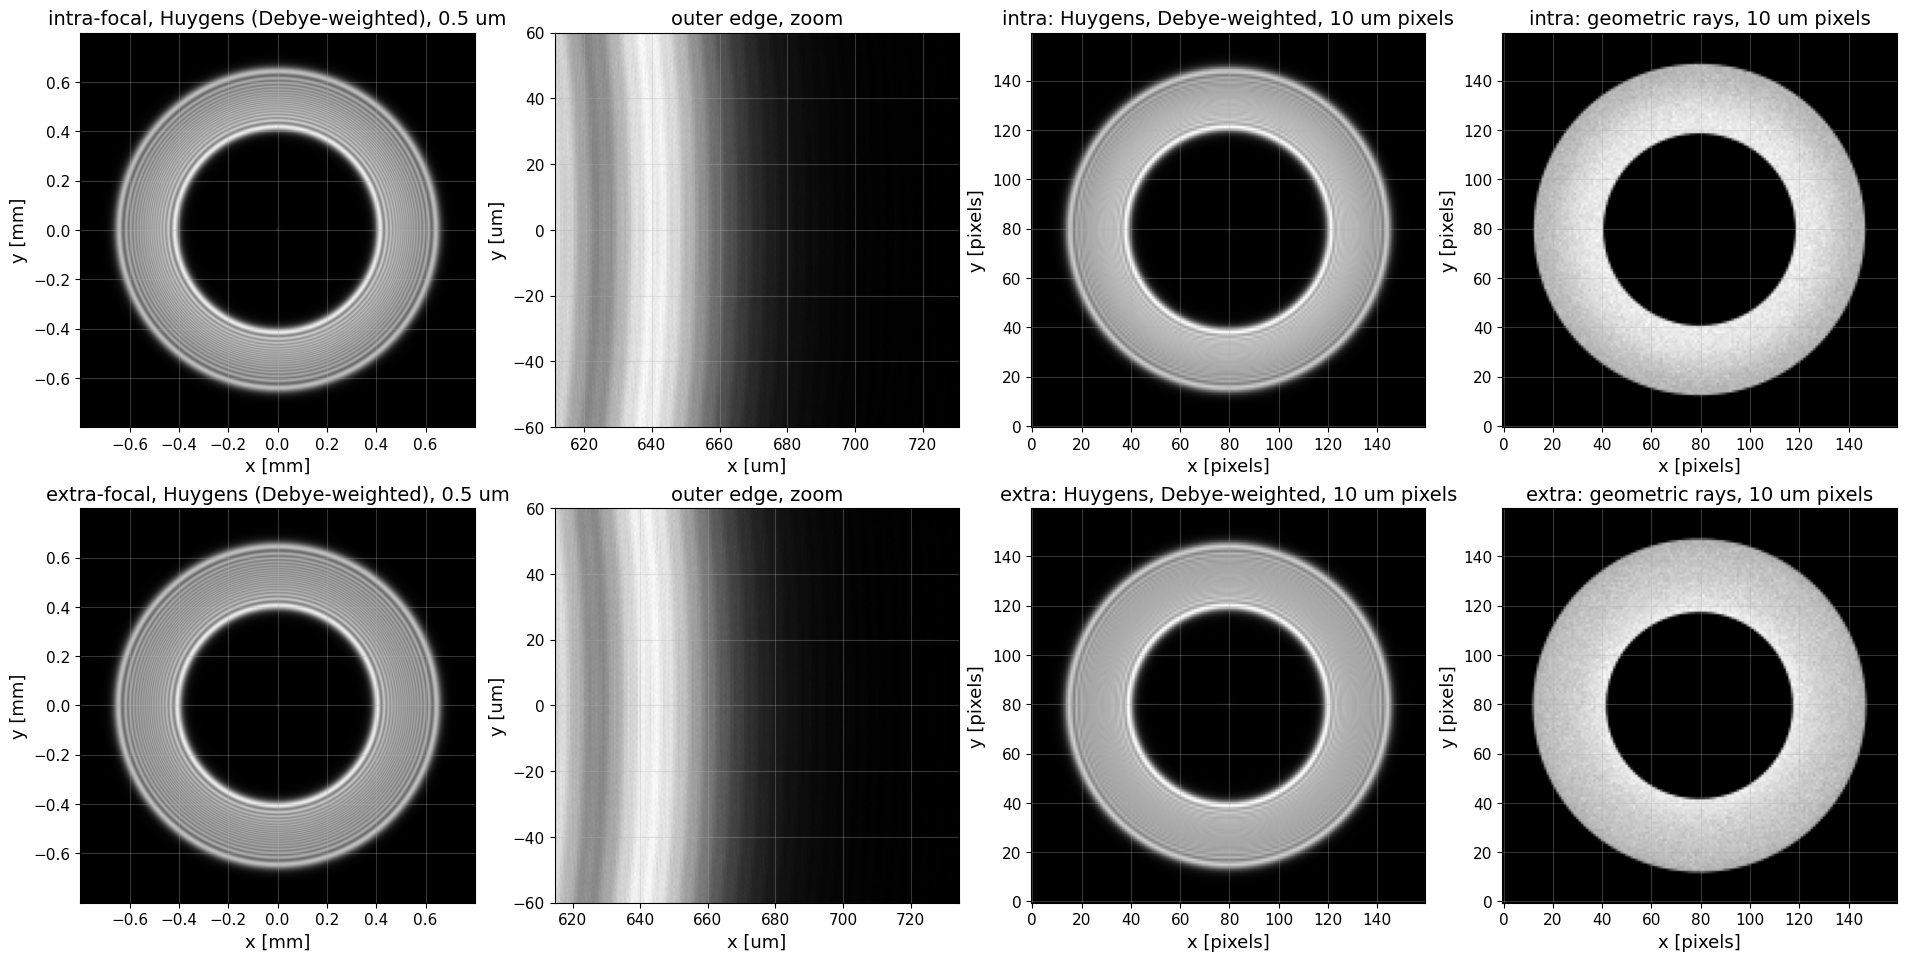

In [8]:
pix = {}
for side, r in res.items():
    c = r['center']
    pix[side] = {
        'Huygens, Debye-weighted': grid_pixels(r['img_w'], r['xs'], r['ys'], c),
        'Huygens, unit weights': grid_pixels(r['img_u'], r['xs'], r['ys'], c),
        'fftPSF': fd.bin_to_pixels(*r['fft'], c, pixel_size, npix_pixel),
        'geometric rays': fd.bin_to_pixels(*r['geo'], None, c, pixel_size, npix_pixel),
    }

fig, axes = plt.subplots(2, 4, figsize=(19, 9.5))
for row, side in enumerate(['intra', 'extra']):
    r = res[side]
    ext = np.array([r['xs'][0], r['xs'][-1], r['ys'][0], r['ys'][-1]]) * 1e3
    axes[row, 0].imshow(r['img_w'], origin='lower', extent=ext, cmap='gray')
    axes[row, 0].set_title(f'{side}-focal, Huygens (Debye-weighted), 0.5 um')
    axes[row, 0].set_xlabel('x [mm]'); axes[row, 0].set_ylabel('y [mm]')
    iy = np.argmin(np.abs(r['ys'] - r['center'][1]))
    xg, yg = r['geo']
    r_out = np.max(np.hypot(xg - r['center'][0], yg - r['center'][1]))
    zx = np.abs(r['xs'] - r['center'][0] - r_out) < 60e-6
    axes[row, 1].imshow(r['img_w'][iy - 120:iy + 120][:, zx], origin='lower',
                        aspect='auto', cmap='gray',
                        extent=[(r['xs'][zx][0] - r['center'][0]) * 1e6,
                                (r['xs'][zx][-1] - r['center'][0]) * 1e6, -60, 60])
    axes[row, 1].set_title('outer edge, zoom')
    axes[row, 1].set_xlabel('x [um]'); axes[row, 1].set_ylabel('y [um]')
    for a, name in zip(axes[row, 2:], ['Huygens, Debye-weighted', 'geometric rays']):
        a.imshow(pix[side][name], origin='lower', cmap='gray')
        a.set_title(f'{side}: {name}, 10 um pixels')
        a.set_xlabel('x [pixels]'); a.set_ylabel('y [pixels]')
fig.savefig(output_dir / f'optics_fresnel_rubin_donuts_{output_date}.png', dpi=110)

<a id='profiles'></a>
## 4. Radial profiles

Azimuthally averaged irradiance in 2 µm annuli about the chief-ray point, normalised to
unit flux, for each model and side. The lower panels show the difference from the
Debye-weighted Huygens reference.

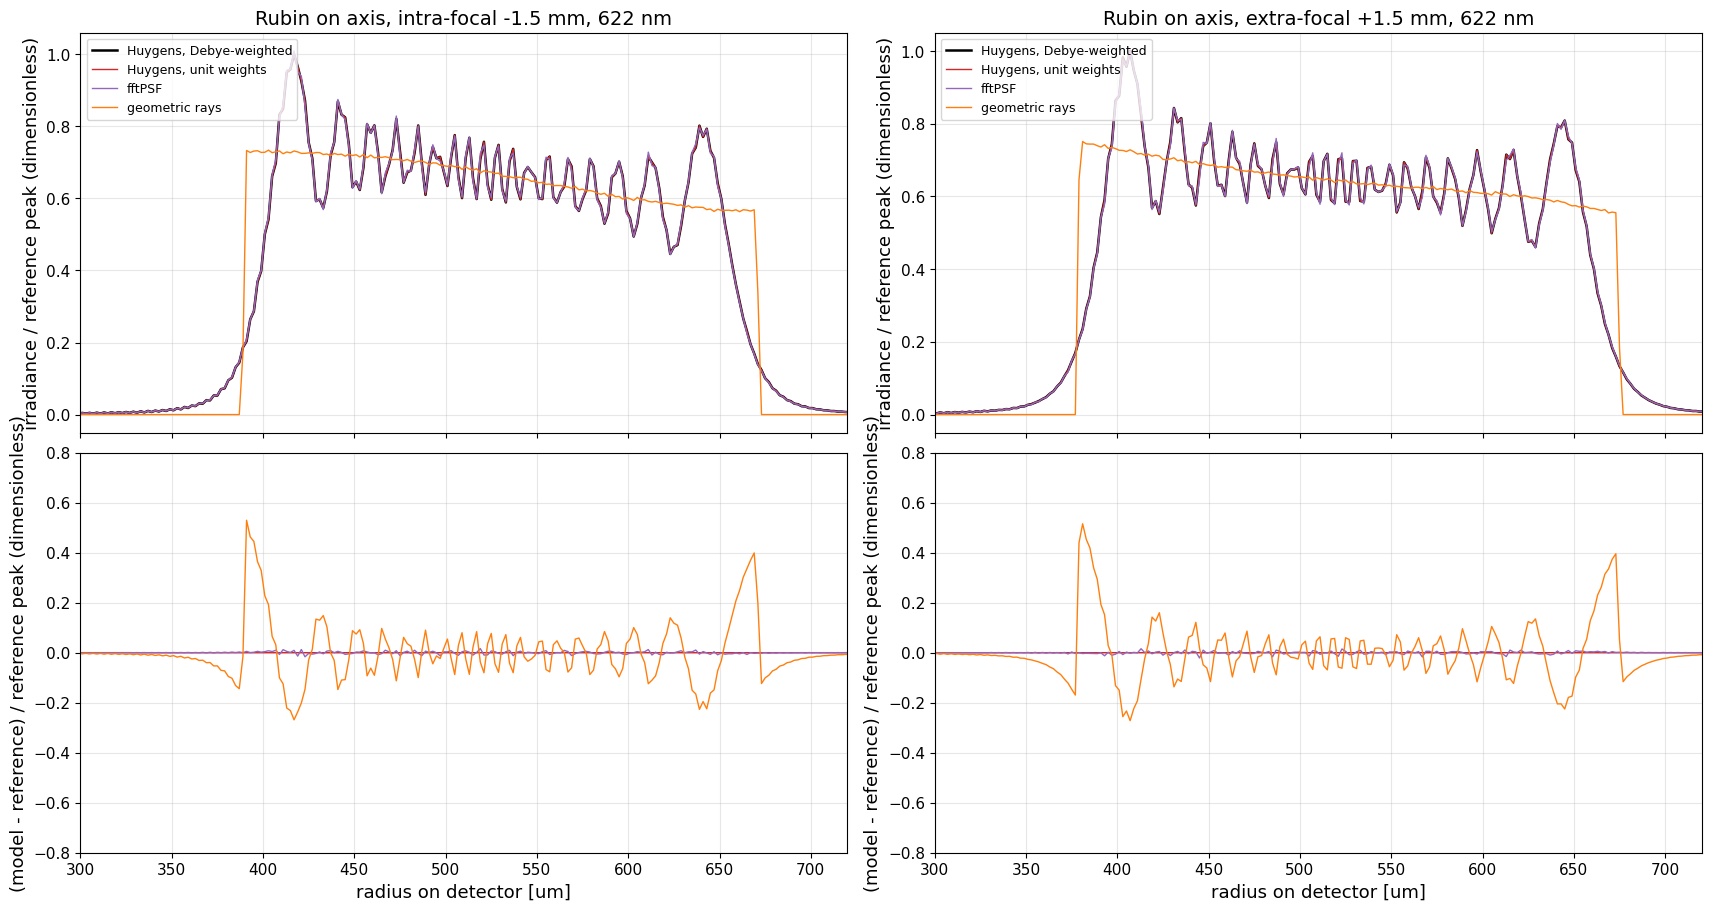

In [9]:
profiles = {}
for side, r in res.items():
    c = r['center']
    profiles[side] = {
        'Huygens, Debye-weighted': grid_profile(r['img_w'], r['xs'], r['ys'], c),
        'Huygens, unit weights': grid_profile(r['img_u'], r['xs'], r['ys'], c),
        'fftPSF': fd.radial_profile(*r['fft'], c, r_edges),
        'geometric rays': fd.radial_profile(*r['geo'], None, c, r_edges),
    }
styles = {'Huygens, Debye-weighted': dict(color='k', lw=1.8),
          'Huygens, unit weights': dict(color='C3', lw=1.0),
          'fftPSF': dict(color='C4', lw=1.0),
          'geometric rays': dict(color='C1', lw=1.0)}
fig, axes = plt.subplots(2, 2, figsize=(17, 9), sharex=True)
for col, side in enumerate(['intra', 'extra']):
    ref = profiles[side]['Huygens, Debye-weighted']
    for name, p in profiles[side].items():
        axes[0, col].plot(r_centers * 1e6, p / ref.max(), label=name, **styles[name])
        if name != 'Huygens, Debye-weighted':
            axes[1, col].plot(r_centers * 1e6, (p - ref) / ref.max(), **styles[name])
    axes[0, col].set_title(f'Rubin on axis, {side}-focal '
                           f'{defocus_values[side]*1e3:+.1f} mm, {wavelength*1e9:.0f} nm')
    axes[0, col].set_ylabel('irradiance / reference peak (dimensionless)')
    axes[1, col].set_ylabel('(model - reference) / reference peak (dimensionless)')
    axes[1, col].set_xlabel('radius on detector [um]')
    axes[1, col].set_ylim(-0.8, 0.8)
    axes[0, col].legend(fontsize=9, loc='upper left')
axes[1, 0].set_xlim(300, 720)
fig.savefig(output_dir / f'optics_fresnel_rubin_profiles_{output_date}.png', dpi=120)

In [10]:
hdr = (f"{'side':6s} {'model':26s} {'r02 [um]':>9s} {'r50 [um]':>9s} {'r98 [um]':>9s} "
       f"{'prof rms [pk]':>14s} {'pix rms [pk]':>13s} {'flux moved [-]':>15s}")
print(hdr); print('-' * len(hdr))
for side in ['intra', 'extra']:
    ref_p = profiles[side]['Huygens, Debye-weighted']
    ref_i = pix[side]['Huygens, Debye-weighted']
    for name, p in profiles[side].items():
        r02, r50, r98 = enclosed_radii(p)
        prms = np.sqrt(np.mean((p - ref_p)**2)) / ref_p.max()
        irms, moved = pixel_stats(pix[side][name], ref_i)
        print(f'{side:6s} {name:26s} {r02*1e6:9.2f} {r50*1e6:9.2f} {r98*1e6:9.2f} '
              f'{prms:14.4f} {irms:13.4f} {moved:15.4f}')
print('prof rms: rms of (model - reference) radial profile in 2 um annuli, fraction of '
      'reference peak irradiance; pix rms: rms over 10 um pixels with reference > 5% of '
      'peak, fraction of reference peak pixel; flux moved: sum |model - reference| over '
      '10 um pixels, fraction of total flux')

side   model                       r02 [um]  r50 [um]  r98 [um]  prof rms [pk]  pix rms [pk]  flux moved [-]
------------------------------------------------------------------------------------------------------------
intra  Huygens, Debye-weighted       397.68    537.40    666.72         0.0000        0.0000          0.0000
intra  Huygens, unit weights         397.68    537.39    666.72         0.0000        0.0000          0.0000
intra  fftPSF                        397.56    537.26    666.54         0.0039        0.0163          0.0155
intra  geometric rays                396.28    537.69    666.09         0.0855        0.1148          0.1328
extra  Huygens, Debye-weighted       386.85    537.76    669.74         0.0000        0.0000          0.0000
extra  Huygens, unit weights         386.85    537.76    669.74         0.0000        0.0000          0.0000
extra  fftPSF                        386.95    537.89    669.85         0.0044        0.0144          0.0143
extra  geometric ra

<a id='pixels'></a>
## 5. Pixel-level comparison (10 µm pixels)

Residuals of each model against the Debye-weighted Huygens reference, as a fraction of
the reference's peak pixel.

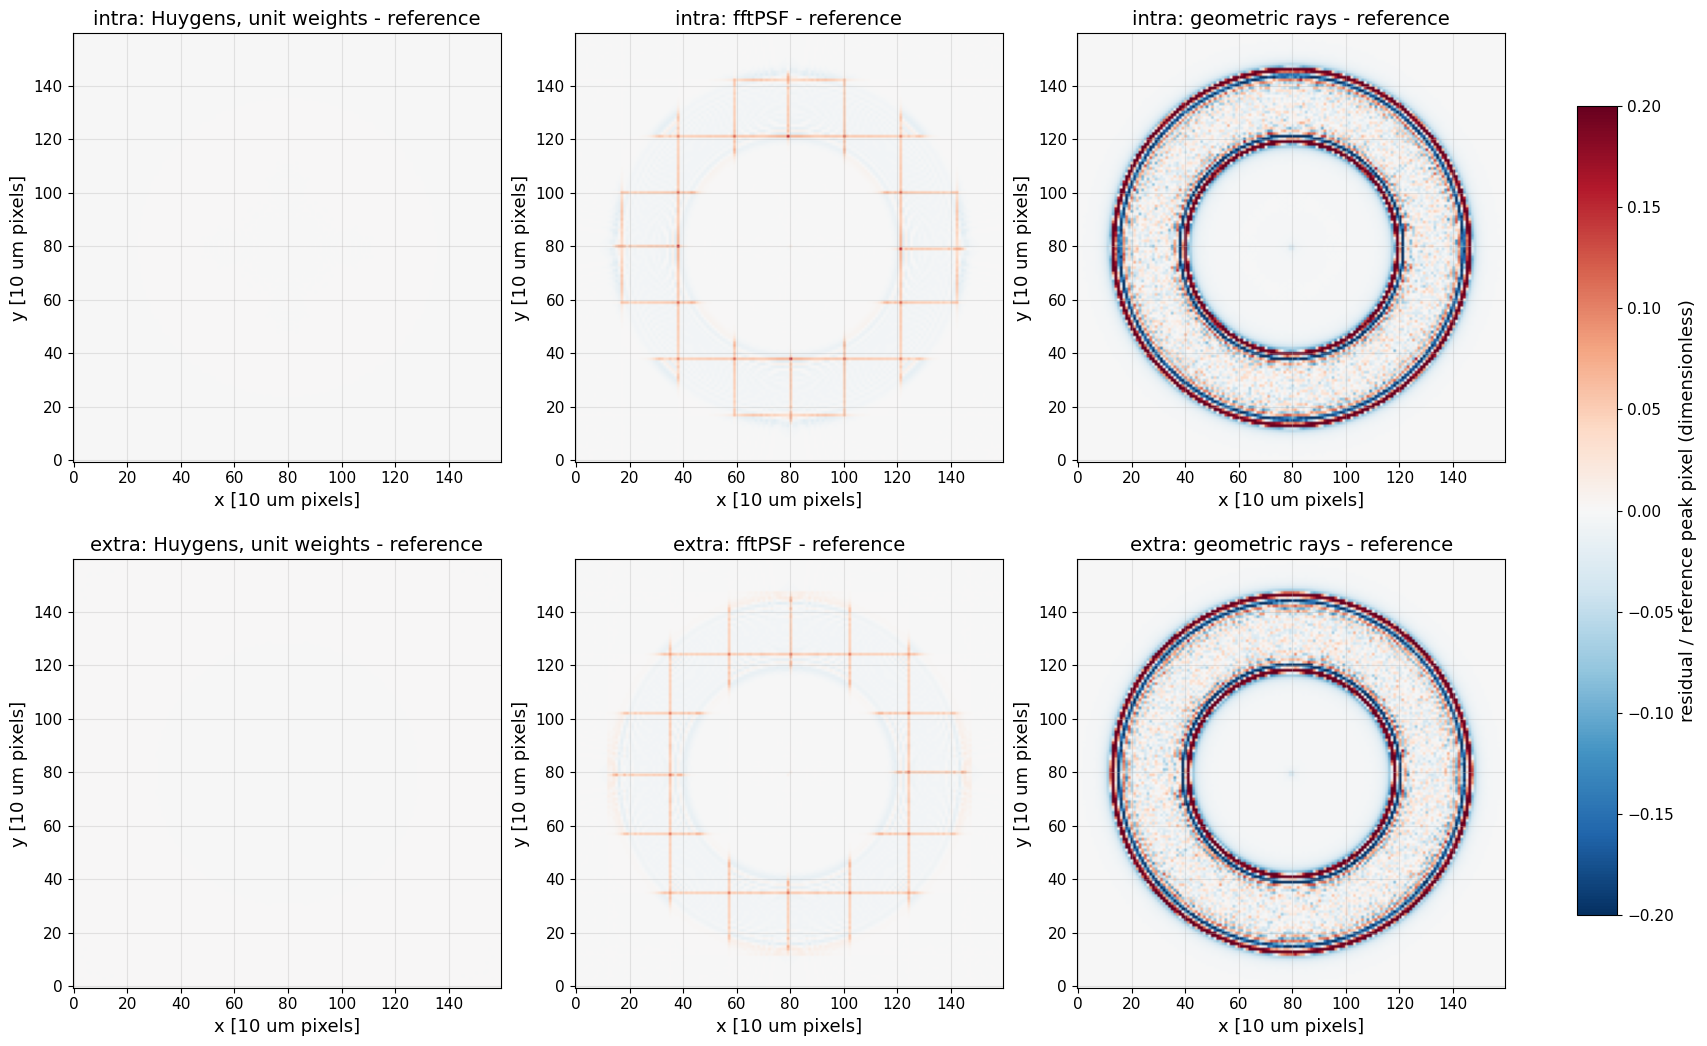

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10.5))
for row, side in enumerate(['intra', 'extra']):
    ref = pix[side]['Huygens, Debye-weighted']
    for a, name in zip(axes[row], ['Huygens, unit weights', 'fftPSF', 'geometric rays']):
        im = a.imshow((pix[side][name] - ref) / ref.max(), origin='lower', cmap='RdBu_r',
                      vmin=-0.2, vmax=0.2)
        a.set_title(f'{side}: {name} - reference')
        a.set_xlabel('x [10 um pixels]'); a.set_ylabel('y [10 um pixels]')
fig.colorbar(im, ax=axes, label='residual / reference peak pixel (dimensionless)',
             shrink=0.8)
fig.savefig(output_dir / f'optics_fresnel_rubin_pixel_residuals_{output_date}.png', dpi=110)

<a id='fftpsf'></a>
## 6. fftPSF sample by sample, and the reference-sphere radius

Binning `fftPSF`'s 0.766 µm lattice into 10 µm pixels puts 13 or 14 lattice columns
into each pixel, which modulates the pixel flux by several percent. That inflates the
`fftPSF` rows of the table above. Here the unit-weight Huygens sum is evaluated on
exactly the `fftPSF` lattice with the NUFFT, so the two can be compared sample by
sample. Both are then binned identically, which cancels the binning artefact.

`fftPSF` measures the wavefront on a reference sphere of radius `sphereRadius`
(5 m in the Rubin yaml files) centred on the chief-ray point. Each ray's phase is
assigned to that ray's own direction, but a Debye treatment would assign it to the
direction of the sphere point as seen from the sphere centre. For a donut the
transverse ray aberration is ~0.66 mm, so the two directions differ by ~0.66 mm / R.
The resulting phase error scales roughly as k·(0.66 mm)²/(2R) and falls as 1/R.

In [12]:
sphere_radii = [2.69, 5.0, 20.0, 100.0, 1000.0]   # m; 2.69 m ~ exit-pupil distance
print(f"{'side':6s} {'sphereRadius [m]':>17s} {'sample rms [pk]':>16s} "
      f"{'sample flux moved [-]':>22s} {'pix rms [pk]':>13s} {'pix flux moved [-]':>19s}")
fft_scan = {}
for side, r in res.items():
    c = r['center']
    for Rs in sphere_radii:
        x, y, v, sp = fd.fftpsf_samples(optics[side], wavelength, nx_pupil, 1,
                                        theta_x, theta_y, sphere_radius=Rs)
        n = int(np.sqrt(len(x)))
        X, Y, F = (a.reshape(n, n) for a in (x + c[0], y + c[1], v))
        H = fd.huygens_on_lattice(r['rays'], wavelength, X, Y)
        m = H > 0.05 * H.max()
        s_rms = np.sqrt(np.mean((F - H)[m]**2)) / H.max()
        s_moved = np.abs(F - H).sum()
        pf = fd.bin_to_pixels(X.ravel(), Y.ravel(), F.ravel(), c, pixel_size, npix_pixel)
        ph = fd.bin_to_pixels(X.ravel(), Y.ravel(), H.ravel(), c, pixel_size, npix_pixel)
        p_rms, p_moved = pixel_stats(pf, ph)
        fft_scan[(side, Rs)] = (s_rms, s_moved, p_rms, p_moved)
        print(f'{side:6s} {Rs:17.2f} {s_rms:16.2e} {s_moved:22.2e} {p_rms:13.2e} {p_moved:19.2e}')
print('sample rms: over lattice samples with Huygens > 5% of peak, fraction of Huygens peak '
      'sample; flux moved: sum |fftPSF - Huygens|, fraction of total flux; pix: after '
      'identical binning of both to 10 um pixels')

side    sphereRadius [m]  sample rms [pk]  sample flux moved [-]  pix rms [pk]  pix flux moved [-]


intra               2.69         5.15e-03               1.58e-02      3.94e-03            5.87e-03


intra               5.00         2.70e-03               8.23e-03      2.00e-03            2.98e-03


intra              20.00         5.94e-04               1.78e-03      3.93e-04            4.98e-04


intra             100.00         2.51e-04               7.79e-04      3.36e-04            4.94e-04


...

extra               2.69         9.61e-03               1.51e-02      4.05e-03            5.72e-03


extra               5.00         4.73e-03               7.41e-03      1.97e-03            2.78e-03


extra              20.00         6.07e-04               9.82e-04      1.84e-04            2.36e-04


extra             100.00         8.52e-04               1.36e-03      3.64e-04            4.95e-04


extra            1000.00         1.08e-03               1.72e-03      4.69e-04            6.45e-04
sample rms: over lattice samples with Huygens > 5% of peak, fraction of Huygens peak sample; flux moved: sum |fftPSF - Huygens|, fraction of total flux; pix: after identical binning of both to 10 um pixels


### Noise floor of the geometric image

The geometric image is a histogram of about 10⁷ rays, so its pixel residuals include
shot noise. Two independent sets of rays, compared with each other, give the noise
floor of the geometric rows in the table.

In [13]:
c = res['extra']['center']
xg2, yg2 = fd.geometric_positions(optics['extra'], wavelength, n_geometric_rays,
                                  theta_x, theta_y, seed=1)
geo2 = fd.bin_to_pixels(xg2, yg2, None, c, pixel_size, npix_pixel)
rms, moved = pixel_stats(geo2, pix['extra']['geometric rays'])
print(f'geometric seed 1 vs seed 0 (extra): rms {rms:.4f} (fraction of peak pixel), '
      f'flux moved {moved:.4f} (fraction of total flux)')
del xg2, yg2

geometric seed 1 vs seed 0 (extra): rms 0.0351 (fraction of peak pixel), flux moved 0.0363 (fraction of total flux)


<a id='intraextra'></a>
## 7. Intra- versus extra-focal

For a perfect optic the two donuts would have identical irradiance (the fields are
complex conjugates). Any difference comes from the aberrations of the defocused beam:
batoid's traced path includes the exact non-paraxial defocus and Rubin's own on-axis
wavefront error. Below: Zernike coefficients of the traced wavefront on each side,
then intra − extra for the reference and for the geometric model. On axis the donut is
rotationally symmetric, so intra and extra can be compared directly, without the
180° flip that an off-axis comparison would need.

intra: Z4 -23.787, Z11 -0.1634, Z22 -0.01950 (um of wavefront, Noll, annular eps 0.612)
extra: Z4 +23.725, Z11 +0.2668, Z22 -0.01094 (um of wavefront, Noll, annular eps 0.612)


intra vs extra, Huygens, Debye-weighted: rms difference 0.1105 (fraction of extra peak pixel), flux moved 0.1262 (fraction of total flux)
intra vs extra, geometric rays: rms difference 0.1458 (fraction of extra peak pixel), flux moved 0.0992 (fraction of total flux)


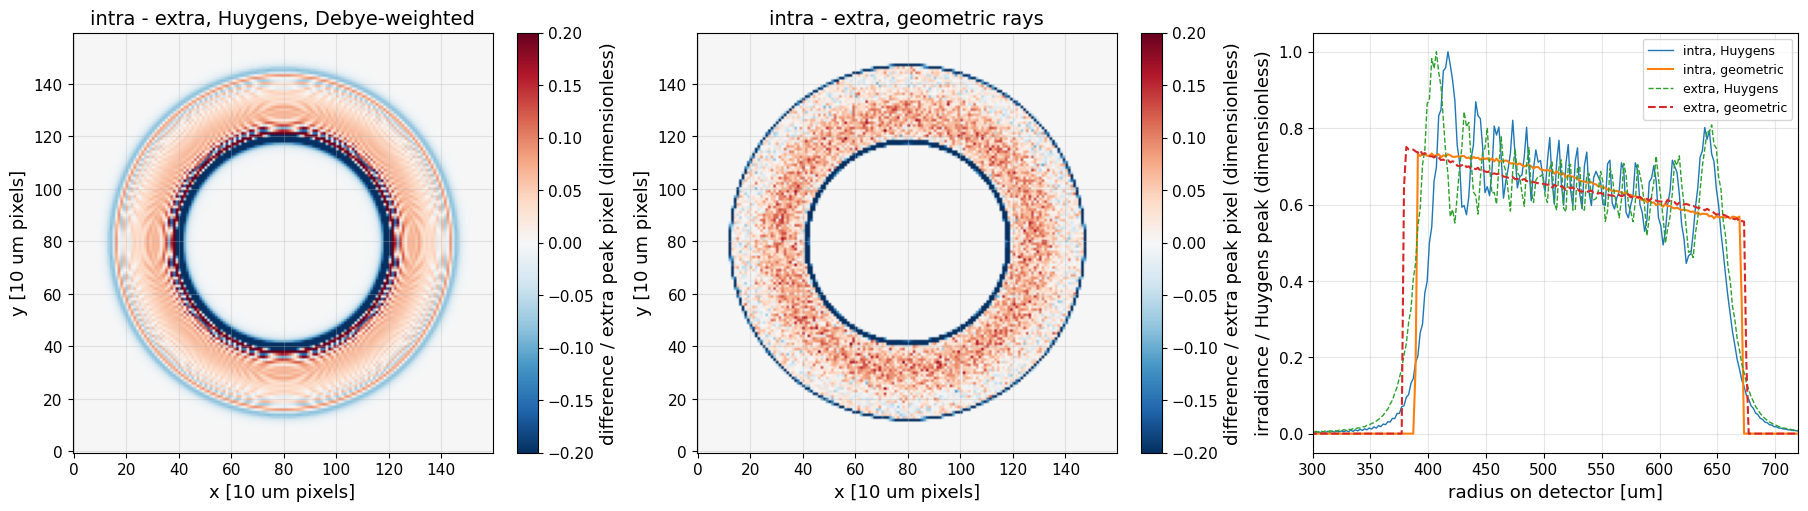

In [14]:
for side, optic in optics.items():
    zk = batoid.analysis.zernike(optic, theta_x, theta_y, wavelength, nx=256, jmax=22,
                                 eps=0.612)
    zk_um = zk * wavelength * 1e6
    print(f'{side}: Z4 {zk_um[4]:+.3f}, Z11 {zk_um[11]:+.4f}, Z22 {zk_um[22]:+.5f} '
          f'(um of wavefront, Noll, annular eps 0.612)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for a, name in zip(axes[:2], ['Huygens, Debye-weighted', 'geometric rays']):
    ref = pix['extra'][name]
    im = a.imshow((pix['intra'][name] - ref) / ref.max(), origin='lower', cmap='RdBu_r',
                  vmin=-0.2, vmax=0.2)
    a.set_title(f'intra - extra, {name}')
    a.set_xlabel('x [10 um pixels]'); a.set_ylabel('y [10 um pixels]')
    fig.colorbar(im, ax=a, label='difference / extra peak pixel (dimensionless)')
for side, ls in [('intra', '-'), ('extra', '--')]:
    p = profiles[side]['Huygens, Debye-weighted']
    axes[2].plot(r_centers * 1e6, p / p.max(), ls, lw=1, label=f'{side}, Huygens')
    g = profiles[side]['geometric rays']
    axes[2].plot(r_centers * 1e6, g / p.max(), ls, lw=1.5, label=f'{side}, geometric')
axes[2].set_xlim(300, 720)
axes[2].set_xlabel('radius on detector [um]')
axes[2].set_ylabel('irradiance / Huygens peak (dimensionless)')
axes[2].legend(fontsize=9)
fig.savefig(output_dir / f'optics_fresnel_rubin_intra_extra_{output_date}.png', dpi=110)
for name in ['Huygens, Debye-weighted', 'geometric rays']:
    rms, moved = pixel_stats(pix['intra'][name], pix['extra'][name])
    print(f'intra vs extra, {name}: rms difference {rms:.4f} (fraction of extra peak '
          f'pixel), flux moved {moved:.4f} (fraction of total flux)')

<a id='conclusions'></a>
## 8. Conclusions

Monochromatic (622 nm), on axis, design prescription, whole camera pistoned ±1.5 mm
(full-array-mode geometry). Numbers are from this run and are reproduced by the cells
above.

- **The reference is converged.** Going from a 2560² to a 3584² pupil grid changes the
  Huygens profile by 1.3×10⁻⁴ RMS of the peak irradiance, and the 10 µm pixel image by
  7.7×10⁻⁴ in Σ|Δ| (fraction of total flux).
- **Rubin obeys the Abbe sine condition** to 8.6×10⁻⁶ in the defocused-camera
  configuration (dimensionless: standard deviation of sin θ/h over the pupil divided by
  its mean), with f_eff = 10.3115 m. The Debye weights vary by ±1.5% (fraction of the
  mean amplitude weight), but that variation cancels against the γ flux projection. As
  a result:
  - **batoid's Huygens sum with its default unit weights is correct for Rubin.** The
    unit-weight and Debye-weighted profiles agree to < 10⁻⁴. What makes `huygensPSF`
    unusable is only its per-pixel loop: ~37 ms per output point at 3.2×10⁶ rays
    (measured in the benchmark notebook with the same ray count), against ~1 s for a
    whole image with the NUFFT.
  - **`fftPSF`'s linear pupil-to-direction map is essentially exact for Rubin**, unlike
    for the paraboloid (7.2×10⁻³ on the same statistic).
- **`fftPSF`'s remaining error comes mainly from the reference-sphere radius.**
  Compared sample by sample with the Huygens sum on its own lattice, the default
  `sphereRadius` of 5 m gives 2.7–4.7×10⁻³ RMS of the peak sample and Σ|Δ| of
  0.7–0.8% of total flux. At 20 m this drops to ~6×10⁻⁴ RMS and 0.10–0.18% of flux,
  and does not improve further at 100–1000 m: a ~0.1% floor, attributed to the small
  remaining departure from a linear pupil map. **For donuts, pass
  `sphereRadius ≳ 20 m`.** Binning the 0.766 µm lattice straight into 10 µm pixels adds
  a separate beat artefact of ~1.5% of the peak pixel.
- **Diffraction is a large effect at the pixel level.** Against geometric ray tracing,
  the diffraction images differ by Σ|Δ| = 13.1–13.3% of total flux and by 11.3–11.5%
  RMS of the peak pixel, well above the 3.6% shot-noise floor of the 10⁷-ray geometric
  histogram. The difference is concentrated in ~3-pixel rings at the inner and outer
  edges (√(λΔz) ≈ 30 µm), plus interior fringes. The half-flux radii agree to 0.3 µm.
- **Intra- and extra-focal donuts differ** even for the design optic:

  | | Intra-focal | Extra-focal |
  |---|---|---|
  | Geometric inner radius | 389.5 µm | 378.3 µm |
  | Geometric outer radius | 671.2 µm | 674.7 µm |
  | Traced Z11 (µm of wavefront, Noll) | −0.163 | +0.267 |

  The Z11 values split into a defocus-induced antisymmetric part of 0.215 µm and an
  in-focus part of 0.052 µm. For the detector-only (CWFS) shift the antisymmetric part
  is 0.177 µm. The Huygens intra and extra donuts differ by Σ|Δ| of 12.6% of total flux.
- **Caveats.** These are monochromatic images, so the interior fringe contrast is
  overstated relative to a broadband exposure. On axis there is no vignetting by the
  camera lenses, so the non-pupil-conjugate edges where Debye itself could fail are not
  tested.
